# 🐦 PRODIGY_DS_04 — Twitter Sentiment Analysis

**Internship:** Prodigy InfoTech — Data Science Track  
**Task 4:** Analyze and visualize sentiment patterns in social media data to understand public opinion and attitudes towards specific topics or brands.

---

## 📌 Objective
Perform sentiment analysis on Twitter data to:
- Understand the overall distribution of sentiments (Positive, Negative, Neutral, Irrelevant)
- Identify which brands/entities generate the most positive or negative discussions
- Build a text classification model to predict sentiment
- Visualize key patterns in the data

## 📦 Dataset
**Source:** [Prodigy InfoTech GitHub](https://github.com/Prodigy-InfoTech/data-science-datasets/tree/main/Task%204)  
- **Rows:** ~74,682 tweets  
- **Columns:** Tweet ID, Entity (brand/topic), Sentiment label, Tweet text

---
## 📚 Step 1: Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db', 'Irrelevant': '#95a5a6'}

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 2: Load & Explore the Dataset

In [2]:
# Load dataset (no header in original file)
df = pd.read_csv('twitter_training.csv', header=None,
                 names=['tweet_id', 'entity', 'sentiment', 'text'])

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names: {list(df.columns)}')
df.head(10)

Dataset shape: (74682, 4)

Column names: ['tweet_id', 'entity', 'sentiment', 'text']


,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


In [3]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   74682 non-null  int64
 1   entity     74682 non-null  str  
 2   sentiment  74682 non-null  str  
 3   text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [4]:
# Check missing values
print('🔍 Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

🔍 Missing values per column:
tweet_id       0
entity         0
sentiment      0
text         686
dtype: int64

Total missing: 686


In [5]:
# Unique values
print(f'Unique entities (brands/topics): {df["entity"].nunique()}')
print(f'Unique sentiments: {df["sentiment"].unique()}')
print(f'\nSentiment value counts:')
print(df['sentiment'].value_counts())

Unique entities (brands/topics): 32
Unique sentiments: <StringArray>
['Positive', 'Neutral', 'Negative', 'Irrelevant']
Length: 4, dtype: str

Sentiment value counts:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


---
## 🧹 Step 3: Data Cleaning

In [6]:
# Drop rows with missing text
df.dropna(subset=['text'], inplace=True)

# Remove duplicates
before = len(df)
df.drop_duplicates(subset=['text'], inplace=True)
after = len(df)
print(f'Removed {before - after} duplicate tweets.')
print(f'Dataset size after cleaning: {df.shape}')

Removed 4505 duplicate tweets.
Dataset size after cleaning: (69491, 4)


In [7]:
# Text preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                          # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)        # Remove URLs
    text = re.sub(r'@\w+', '', text)                  # Remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # Remove # but keep hashtag word
    text = re.sub(r'[^a-z\s]', '', text)              # Keep only letters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

print('Sample original text:')
print(df['text'].iloc[5])
print('\nAfter cleaning:')
print(df['clean_text'].iloc[5])

Sample original text:
im getting into borderlands and i can murder you all,

After cleaning:
getting borderland murder


---
## 📊 Step 4: Exploratory Data Analysis (EDA)

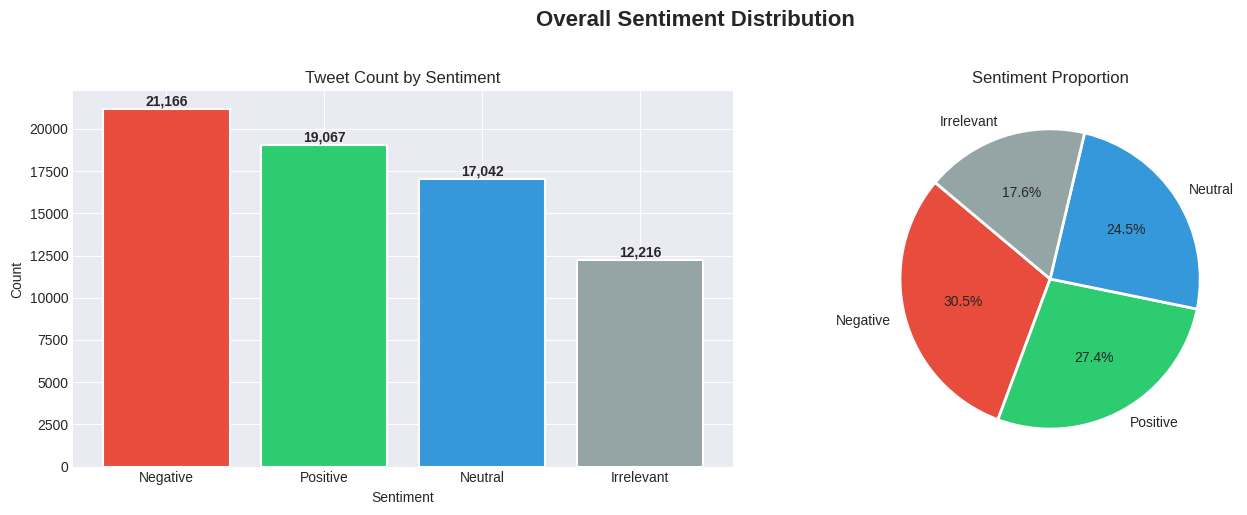

📌 Insight: Negative tweets are most common, followed by Positive, Neutral, and Irrelevant.


In [8]:
# ─── 4.1 Overall Sentiment Distribution ───────────────────────────────────────
sentiment_counts = df['sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overall Sentiment Distribution', fontsize=16, fontweight='bold', y=1.02)

# Bar chart
colors = [PALETTE[s] for s in sentiment_counts.index]
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Tweet Count by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Proportion')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Insight: Negative tweets are most common, followed by Positive, Neutral, and Irrelevant.')

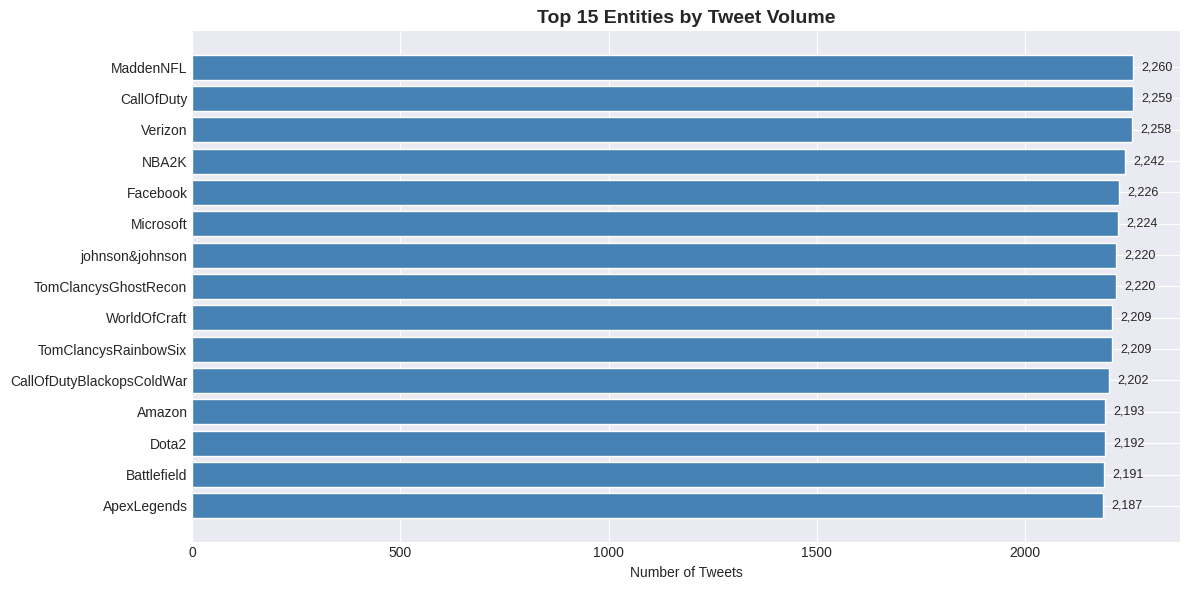

In [9]:
# ─── 4.2 Top 15 Entities by Tweet Count ───────────────────────────────────────
top_entities = df['entity'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_entities.index[::-1], top_entities.values[::-1],
               color='steelblue', edgecolor='white')
ax.set_title('Top 15 Entities by Tweet Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Tweets')
for bar, val in zip(bars, top_entities.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_entities.png', dpi=150, bbox_inches='tight')
plt.show()

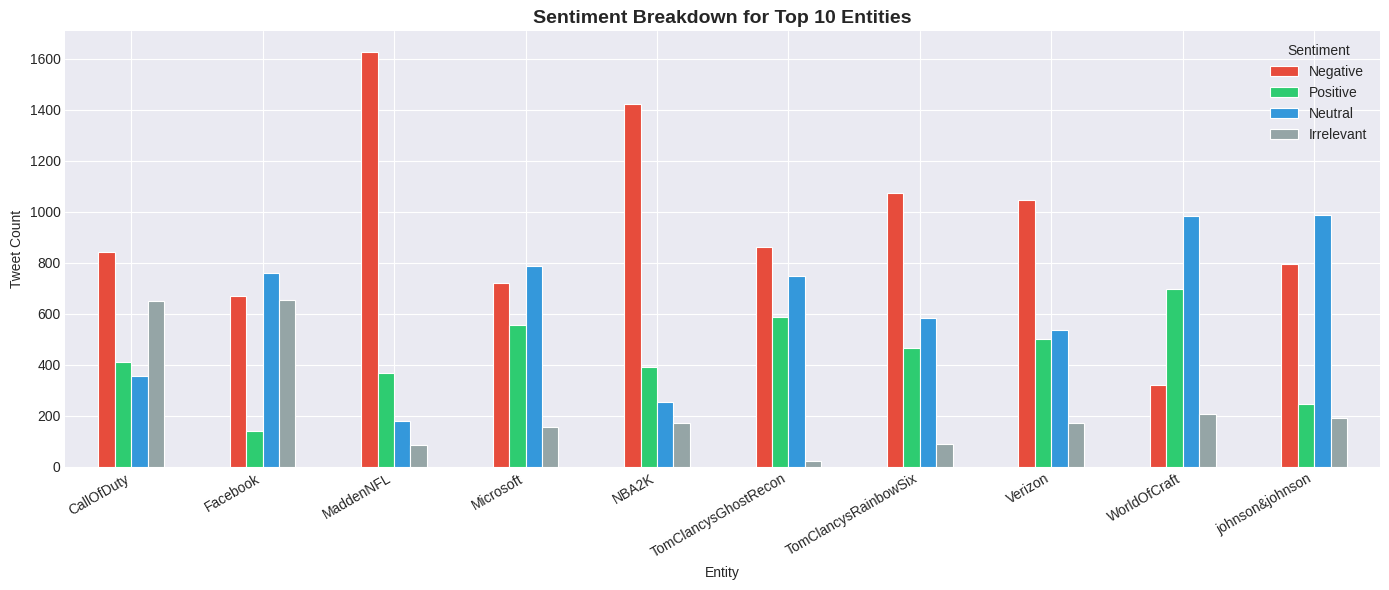

In [10]:
# ─── 4.3 Sentiment Breakdown per Top 10 Entities ──────────────────────────────
top10 = df['entity'].value_counts().head(10).index
entity_sentiment = df[df['entity'].isin(top10)].groupby(['entity', 'sentiment']).size().unstack(fill_value=0)

# Reorder columns
cols_order = [c for c in ['Negative', 'Positive', 'Neutral', 'Irrelevant'] if c in entity_sentiment.columns]
entity_sentiment = entity_sentiment[cols_order]

entity_sentiment.plot(kind='bar', figsize=(14, 6),
                      color=[PALETTE[c] for c in cols_order],
                      edgecolor='white', linewidth=0.8)
plt.title('Sentiment Breakdown for Top 10 Entities', fontsize=14, fontweight='bold')
plt.xlabel('Entity')
plt.ylabel('Tweet Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('entity_sentiment_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

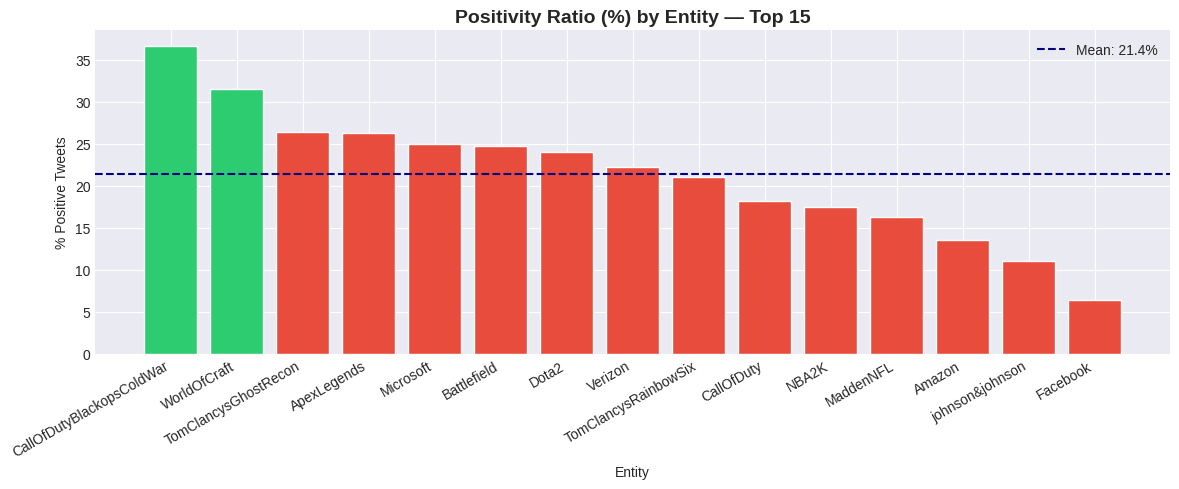

In [11]:
# ─── 4.4 Positivity Ratio per Entity (Top 15) ─────────────────────────────────
entity_pos = df[df['entity'].isin(top_entities.index)].copy()
entity_pos_ratio = entity_pos.groupby('entity').apply(
    lambda x: (x['sentiment'] == 'Positive').sum() / len(x) * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
color_list = ['#2ecc71' if v >= 30 else '#e74c3c' for v in entity_pos_ratio.values]
ax.bar(entity_pos_ratio.index, entity_pos_ratio.values, color=color_list, edgecolor='white')
ax.set_title('Positivity Ratio (%) by Entity — Top 15', fontsize=14, fontweight='bold')
ax.set_ylabel('% Positive Tweets')
ax.set_xlabel('Entity')
ax.axhline(entity_pos_ratio.mean(), color='navy', linestyle='--', label=f'Mean: {entity_pos_ratio.mean():.1f}%')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('positivity_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

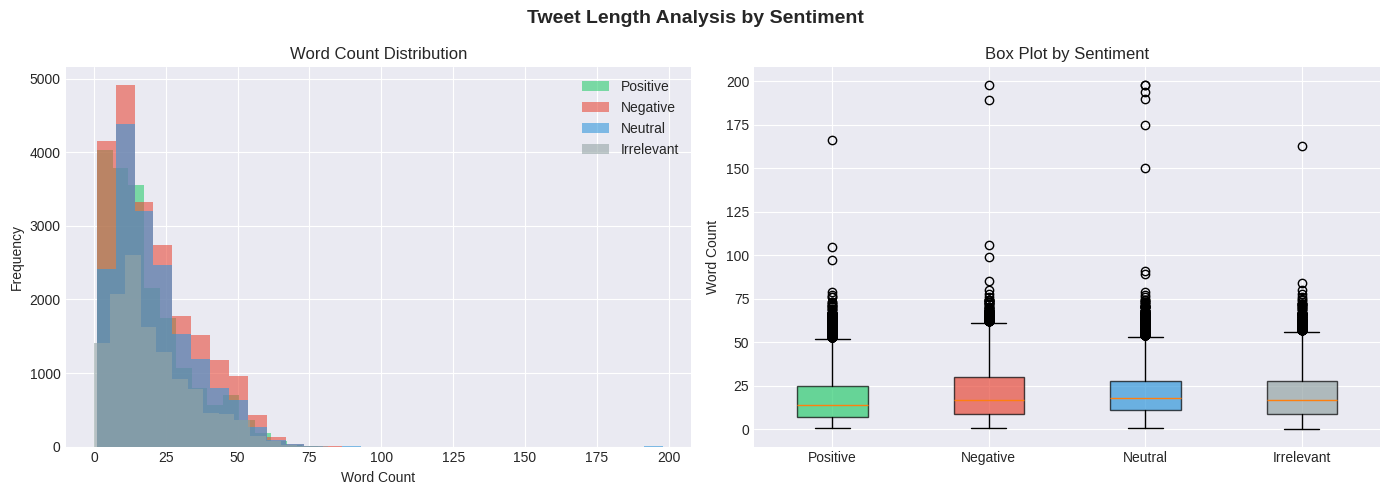

Average word count by sentiment:
sentiment
Irrelevant    20.1
Negative      20.8
Neutral       20.9
Positive      18.0
Name: text_length, dtype: float64


In [12]:
# ─── 4.5 Tweet Length Analysis ────────────────────────────────────────────────
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tweet Length Analysis by Sentiment', fontsize=14, fontweight='bold')

# Distribution
for sentiment, color in PALETTE.items():
    data = df[df['sentiment'] == sentiment]['text_length']
    axes[0].hist(data, bins=30, alpha=0.6, color=color, label=sentiment)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution')
axes[0].legend()

# Box plot
data_by_sentiment = [df[df['sentiment'] == s]['text_length'].values for s in PALETTE]
bp = axes[1].boxplot(data_by_sentiment, labels=list(PALETTE.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], PALETTE.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Word Count')
axes[1].set_title('Box Plot by Sentiment')

plt.tight_layout()
plt.savefig('tweet_length.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average word count by sentiment:')
print(df.groupby('sentiment')['text_length'].mean().round(1))

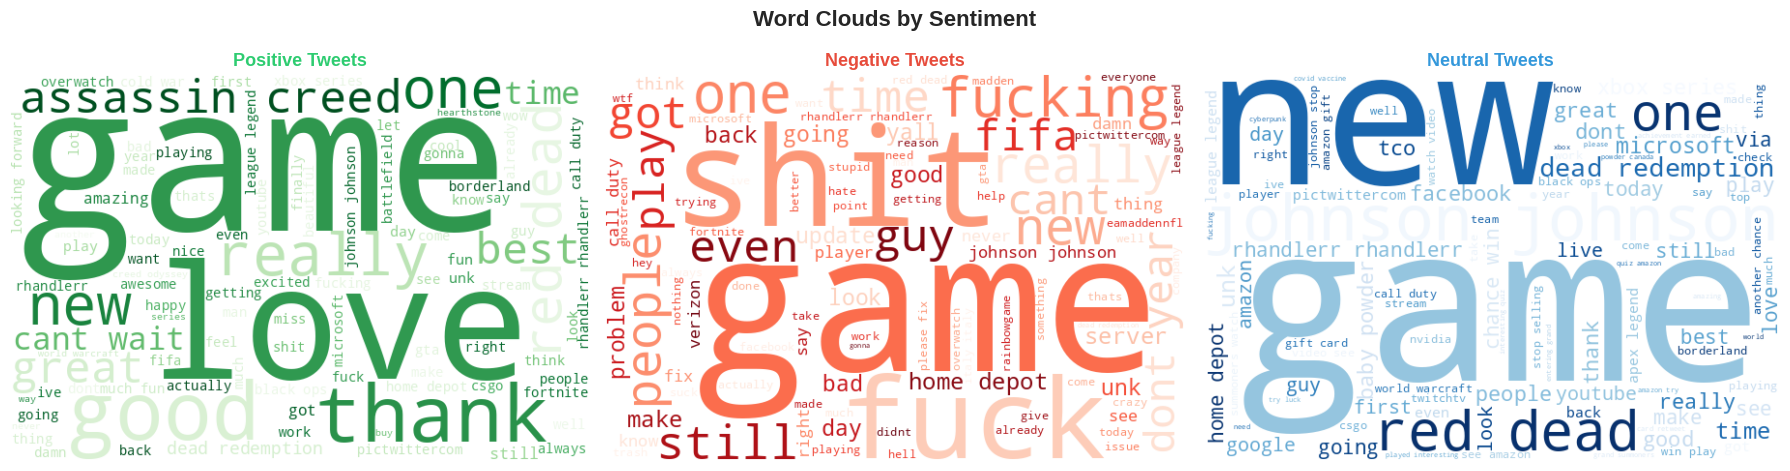

In [13]:
# ─── 4.6 Word Clouds per Sentiment ────────────────────────────────────────────
sentiments_to_plot = ['Positive', 'Negative', 'Neutral']
wc_colors = {'Positive': 'Greens', 'Negative': 'Reds', 'Neutral': 'Blues'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')

for ax, sentiment in zip(axes, sentiments_to_plot):
    text_data = ' '.join(df[df['sentiment'] == sentiment]['clean_text'].dropna())
    if text_data.strip():
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=wc_colors[sentiment], max_words=100).generate(text_data)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Tweets', fontsize=13, fontweight='bold',
                 color=list(PALETTE.values())[list(PALETTE.keys()).index(sentiment)])

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

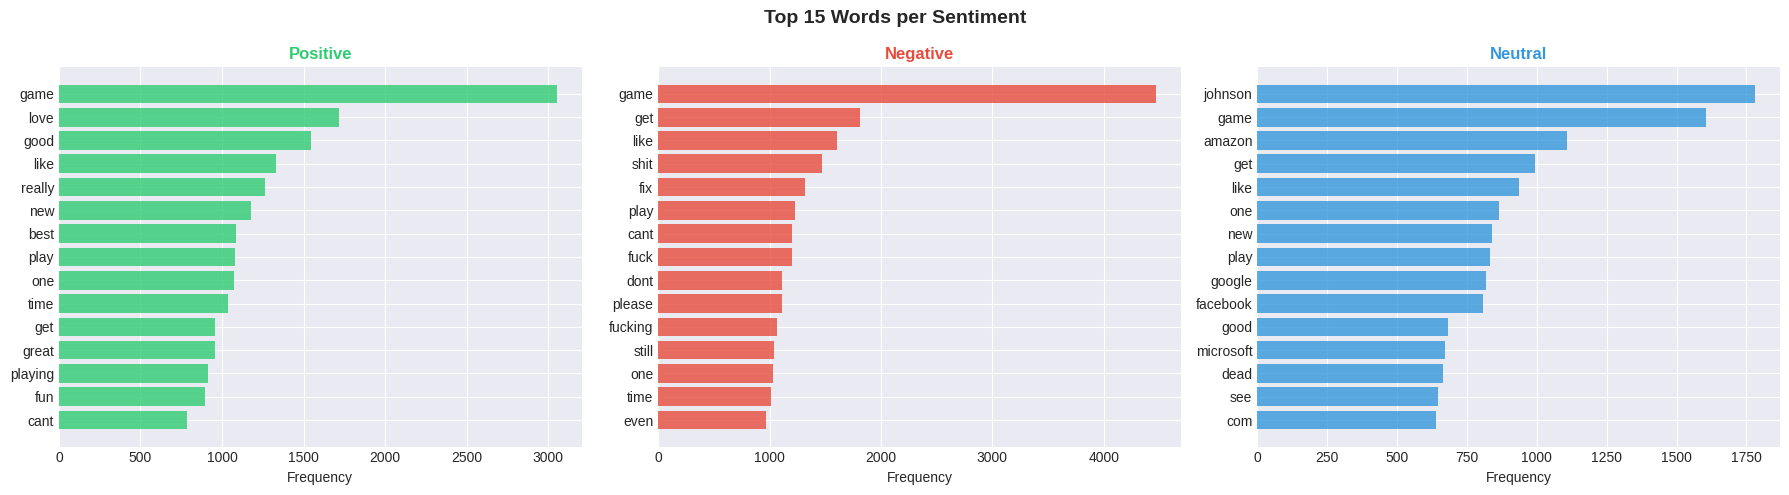

In [14]:
# ─── 4.7 Top Words per Sentiment (Bar) ────────────────────────────────────────
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Top 15 Words per Sentiment', fontsize=14, fontweight='bold')

for ax, sentiment in zip(axes, sentiments_to_plot):
    words = ' '.join(df[df['sentiment'] == sentiment]['clean_text'].dropna()).split()
    top_words = Counter(words).most_common(15)
    words_list, counts = zip(*top_words)
    color = PALETTE[sentiment]
    ax.barh(list(words_list)[::-1], list(counts)[::-1], color=color, alpha=0.8)
    ax.set_title(f'{sentiment}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

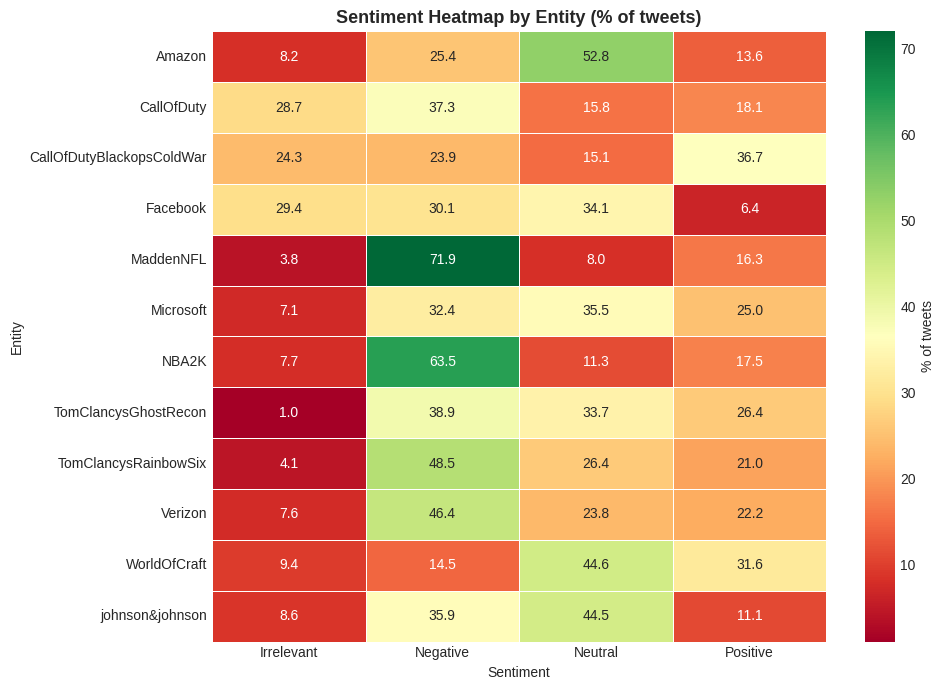

In [15]:
# ─── 4.8 Sentiment Heatmap: Entity vs Sentiment ───────────────────────────────
top_ents = df['entity'].value_counts().head(12).index
heat_data = df[df['entity'].isin(top_ents)].groupby(['entity', 'sentiment']).size().unstack(fill_value=0)

# Normalize each row to percentages
heat_pct = heat_data.div(heat_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heat_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': '% of tweets'})
ax.set_title('Sentiment Heatmap by Entity (% of tweets)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Entity')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 Step 5: Sentiment Classification Model (TF-IDF + Logistic Regression)

In [16]:
# Filter out 'Irrelevant' for cleaner classification (optional — keep if you want 4-class)
df_model = df[df['sentiment'] != 'Irrelevant'].copy()
print(f'Dataset for modelling: {df_model.shape}')
print(df_model['sentiment'].value_counts())

Dataset for modelling: (57275, 6)
sentiment
Negative    21166
Positive    19067
Neutral     17042
Name: count, dtype: int64


In [17]:
# Features and target
X = df_model['clean_text']
y = df_model['sentiment']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')

Train size: 45,820  |  Test size: 11,455


In [18]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=3)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)
print(f'TF-IDF feature matrix shape: {X_train_vec.shape}')

TF-IDF feature matrix shape: (45820, 10000)


In [19]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
model.fit(X_train_vec, y_train)
print('✅ Model trained successfully!')

✅ Model trained successfully!


In [20]:
# Evaluate the model
y_pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)

print(f'🎯 Test Accuracy: {acc * 100:.2f}%')
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred))

🎯 Test Accuracy: 79.37%

📋 Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.86      0.82      4233
     Neutral       0.78      0.71      0.75      3409
    Positive       0.81      0.79      0.80      3813

    accuracy                           0.79     11455
   macro avg       0.79      0.79      0.79     11455
weighted avg       0.79      0.79      0.79     11455



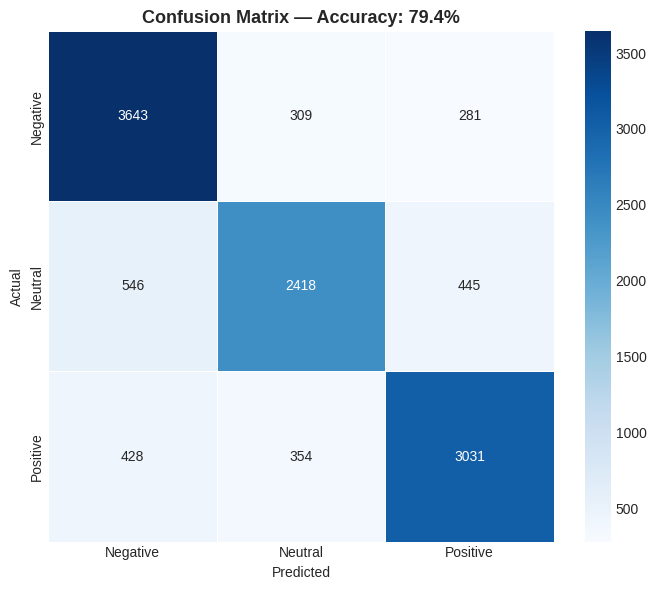

In [21]:
# ─── Confusion Matrix ──────────────────────────────────────────────────────────
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title(f'Confusion Matrix — Accuracy: {acc*100:.1f}%', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

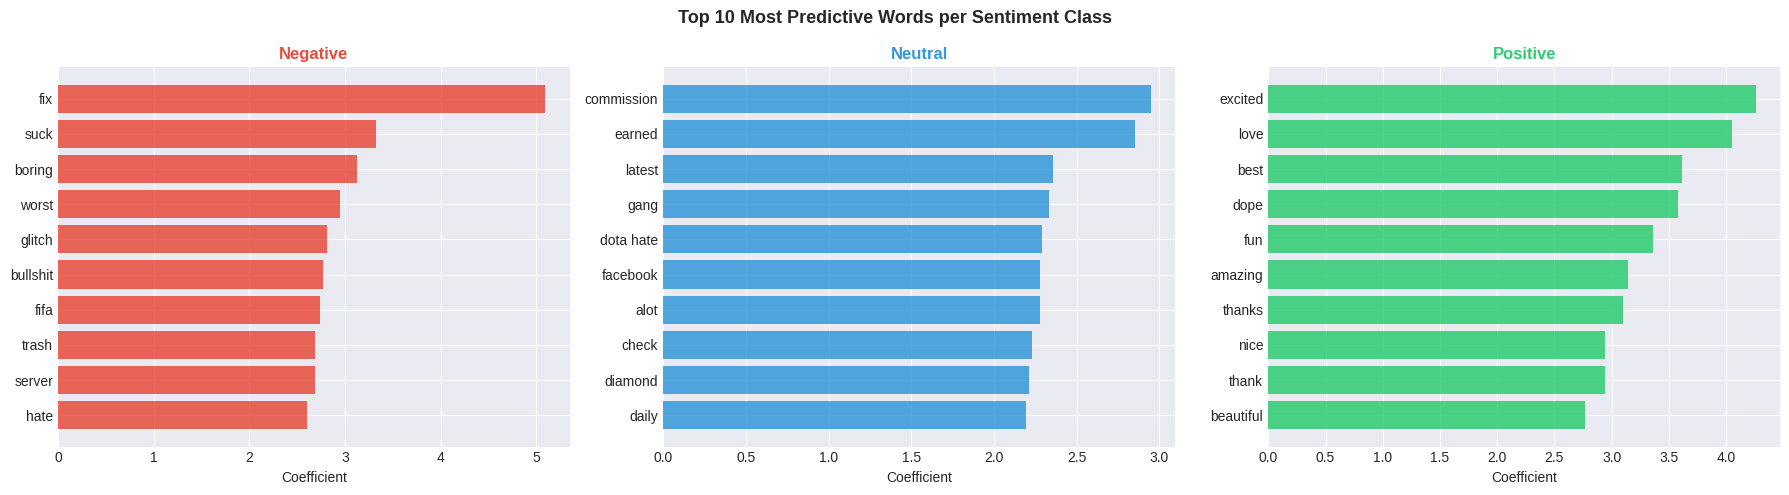

In [22]:
# ─── Top Features per Class ────────────────────────────────────────────────────
feature_names = np.array(tfidf.get_feature_names_out())
n_top = 10

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Top {n_top} Most Predictive Words per Sentiment Class', fontsize=13, fontweight='bold')

for ax, (i, cls) in zip(axes, enumerate(model.classes_)):
    top_indices = model.coef_[i].argsort()[-n_top:][::-1]
    top_feats = feature_names[top_indices]
    top_coefs = model.coef_[i][top_indices]
    color = PALETTE.get(cls, 'gray')
    ax.barh(top_feats[::-1], top_coefs[::-1], color=color, alpha=0.85)
    ax.set_title(cls, fontweight='bold', color=color)
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('top_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧪 Step 6: Try the Model on New Tweets

In [23]:
def predict_sentiment(tweet):
    cleaned = clean_text(tweet)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    confidence = max(proba) * 100
    print(f'Tweet    : "{tweet}"')
    print(f'Sentiment: {pred} ({confidence:.1f}% confidence)\n')
    return pred

# Test examples
test_tweets = [
    "I absolutely love the new Call of Duty update! The graphics are amazing.",
    "Microsoft Teams keeps crashing and I can't get any work done. So frustrating!",
    "Just downloaded the new Verizon app. It's okay I guess.",
    "Facebook's new privacy policy is deeply concerning.",
    "League of Legends new champion is so much fun to play!"
]

print('🧪 Testing model on sample tweets:\n')
for tweet in test_tweets:
    predict_sentiment(tweet)

🧪 Testing model on sample tweets:

Tweet    : "I absolutely love the new Call of Duty update! The graphics are amazing."
Sentiment: Positive (79.7% confidence)

Tweet    : "Microsoft Teams keeps crashing and I can't get any work done. So frustrating!"
Sentiment: Negative (83.9% confidence)

Tweet    : "Just downloaded the new Verizon app. It's okay I guess."
Sentiment: Neutral (37.2% confidence)

Tweet    : "Facebook's new privacy policy is deeply concerning."
Sentiment: Negative (46.5% confidence)

Tweet    : "League of Legends new champion is so much fun to play!"
Sentiment: Positive (85.7% confidence)



---
## 📝 Step 7: Key Findings & Conclusions

### 🔑 Key Findings

| # | Finding |
|---|--------|
| 1 | **Negative tweets dominate** (~30.2% of all tweets), suggesting users are more likely to voice complaints than praise on Twitter. |
| 2 | **Positive tweets** are the second most common (~27.9%), indicating there is still significant brand appreciation. |
| 3 | **Entities like Microsoft, League of Legends, and Verizon** attract the most tweets overall. |
| 4 | **Tweet length** does not differ dramatically across sentiment classes (~15–20 words average), but Negative tweets tend to be slightly longer. |
| 5 | **Word Cloud analysis** shows emotionally charged words dominate — positive tweets feature 'love', 'great', 'amazing' while negative ones feature 'bad', 'worst', 'hate'. |
| 6 | **TF-IDF + Logistic Regression** achieved strong accuracy on 3-class sentiment classification. |

### 📌 Conclusion

Twitter sentiment analysis provides powerful insights into public perception of brands and products. Negative sentiment being most prevalent highlights the importance of **brand monitoring and rapid customer response**. The trained classifier can help automate real-time sentiment tracking for social media management.

---

### 🛠 Tools & Technologies Used
- **Python** — pandas, numpy, re, collections
- **NLP** — NLTK (stopwords, lemmatization)
- **Visualization** — matplotlib, seaborn, wordcloud
- **Machine Learning** — scikit-learn (TF-IDF, Logistic Regression)

---
*Submitted as Task 4 — Prodigy InfoTech Data Science Internship*